# Introduction:

### Name: Muhammad Hasaan Hasan Khan
### Linkedin: [Hasaan's Linkedin](https://www.linkedin.com/in/hasaan-khan-422249289/)
### Github: [Hasaan's Github](https://github.com/hasaankhan175)
### Kaggle: [Hasaan's Kaggle](https://www.kaggle.com/hasaankhan175)
### Portfolio: [Hasaan's Portfolio](https://hasaankhan175.github.io/)


# Objective

The goal of this project is to build a machine learning model that can accurately predict the selling price of used cars based on various features such as vehicle age, present price, fuel type, transmission, and usage (driven kilometers).

This model aims to:

* Help sellers estimate a fair market value for their cars
* Assist buyers in identifying overpriced or undervalued vehicles
* Demonstrate the application of regression techniques in a real-world pricing problem

The project will involve data preprocessing, exploratory data analysis (EDA), feature engineering, model training, and evaluation using regression algorithms.

---

# Data Overview

The dataset used in this project contains information about used cars with multiple features influencing their selling price. Each row represents a single car listing.

### Key Features:

* **Car_Name**: Name/model of the car
* **Year**: Manufacturing year of the car
* **Selling_Price**: Target variable — price at which the car is sold (in lakhs)
* **Present_Price**: Current ex-showroom price of the car (in lakhs)
* **Driven_kms**: Total distance driven (in kilometers)
* **Fuel_Type**: Type of fuel used (Petrol/Diesel/CNG)
* **Selling_type**: Dealer or individual seller
* **Transmission**: Manual or Automatic
* **Owner**: Number of previous owners

### Dataset Characteristics:

* Contains both **numerical and categorical variables**
* Requires **encoding of categorical features**
* May contain **outliers** (e.g., unusually high mileage or price)
* Feature relationships (e.g., car age vs price) are expected to be **non-linear**

---

Now the pushback you need:

* You’re building a **very common project**. Thousands of students do “car price prediction.”
* What’s missing is **your edge**:

  * Are you optimizing for accuracy or interpretability?
  * Are you comparing models (Linear Regression vs Random Forest vs XGBoost)?
  * Are you explaining *why* the model predicts a certain price?

If you don’t answer that, this becomes just another copy-paste portfolio project.

If you want, I can help you turn this into something that actually stands out (feature importance, deployment, UI, etc.).


In [19]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [20]:
# Importing the dataset
data = pd.read_csv('Car data.csv')
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [21]:
current_year = 2025
data['Car_Age'] = current_year - data['Year']
data.drop('Year', axis=1, inplace=True)

Why?
Models understand age impact, not raw year.

In [22]:
data['Owner'] = data['Owner'].astype('category')

Because it represents a limited set of discrete states (0, 1, 3), not a continuous quantity where arithmetic operations like “twice as many owners” have real statistical meaning.

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       301 non-null    object  
 1   Selling_Price  301 non-null    float64 
 2   Present_Price  301 non-null    float64 
 3   Driven_kms     301 non-null    int64   
 4   Fuel_Type      301 non-null    object  
 5   Selling_type   301 non-null    object  
 6   Transmission   301 non-null    object  
 7   Owner          301 non-null    category
 8   Car_Age        301 non-null    int64   
dtypes: category(1), float64(2), int64(2), object(4)
memory usage: 19.4+ KB


In [24]:
# statistical description of the dataset
data.describe()

,Selling_Price,Present_Price,Driven_kms,Car_Age
count,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,11.372093
std,5.082812,8.642584,38886.883882,2.891554
min,0.100000,0.320000,500.000000,7.000000
25%,0.900000,1.200000,15000.000000,9.000000
50%,3.600000,6.400000,32000.000000,11.000000
75%,6.000000,9.900000,48767.000000,13.000000
max,35.000000,92.600000,500000.000000,22.000000


#### Visualizing Dataset:

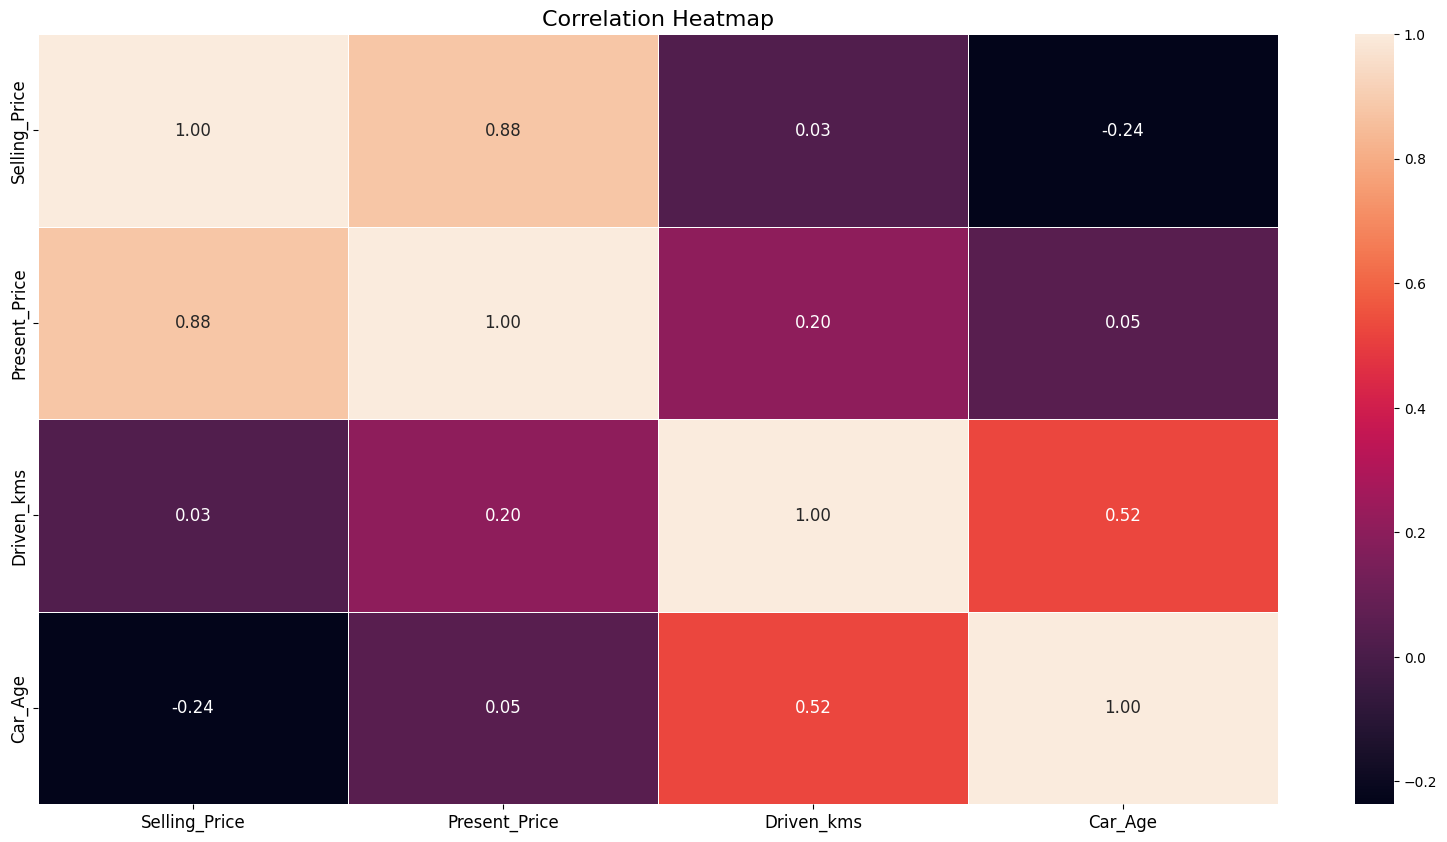

In [27]:
# making heatmap 
numeric_df = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(20, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 12},   # annotation (numbers inside cells)
    linewidths=0.5
)

plt.xticks(fontsize=12)  # x-axis labels
plt.yticks(fontsize=12)  # y-axis labels

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

## Type: Correlation Heatmap

#### Observations:

The heatmap visualizes the correlation matrix between four variables: 'Selling_Price', 'Present_Price', 'Driven_kms', and 'Car_Age'.
The color intensity represents the strength and direction (positive or negative) of the correlation. Lighter colors indicate positive correlations, while darker colors suggest negative correlations.
Values range from -1 to 1, and are annotated on the heatmap.

#### Trends:

There is a strong positive correlation (0.88) between 'Selling_Price' and 'Present_Price'. This suggests that as the present price of a car increases, its selling price also tends to increase.
'Driven_kms' has a moderate positive correlation (0.52) with 'Car_Age'. This makes intuitive sense, as older cars are likely to have been driven more.
There appears to be a weak negative correlation (-0.24) between 'Selling_Price' and 'Car_Age'. This indicates that as the age of the car increases, the selling price tends to decrease slightly.

#### Statistics:

The diagonal elements of the matrix are all 1, indicating a perfect correlation of a variable with itself.
The correlation between 'Driven_kms' and 'Selling_Price' (0.03) and 'Present_Price' (0.20) appears to be weak.

#### Anomalies:

There are no immediately obvious anomalies or outliers based solely on the correlation heatmap.


#### Summary:

The 'Selling_Price' is strongly correlated with 'Present_Price', suggesting the present price is a good predictor of the selling price.
'Car_Age' and 'Driven_kms' have a moderate positive correlation.
The other variable pairs exhibit weak correlations.
Let me know if you'd like a deeper dive into any specific aspect!

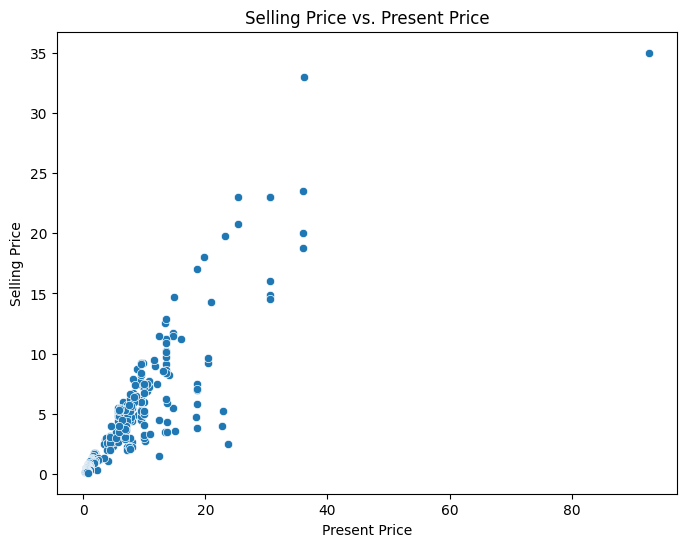

In [30]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=data)
plt.title('Selling Price vs. Present Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.show()

## 📊 Scatter Plot Analysis: Present Price vs Selling Price

### 🔎 Type
- Scatter Plot

---

### 📌 Observations

- The plot shows the relationship between **Present Price (x-axis)** and **Selling Price (y-axis)** of cars.
- Most data points are concentrated in the **lower-left region**, indicating that the majority of cars are low to mid priced in both present and selling value.
- A general upward movement of points suggests that higher present prices are associated with higher selling prices.
- There is noticeable **variation in selling price even for cars with similar present prices**, especially in the lower price range.

---

### 📈 Trends

- **Positive Correlation**  
  Present price and selling price have a clear positive relationship.

- **Non-linear Relationship**  
  The increase in selling price is not perfectly linear; it flattens slightly at higher price ranges.

- **Diminishing Effect at Higher Prices**  
  At higher present prices, selling price does not increase as sharply, suggesting reduced marginal gain.

---

### 📊 Statistical Insight

- Data is heavily **skewed toward lower-priced cars**, meaning:
  - Mean values are likely influenced by lower range values.
  - Median may be more representative than mean.

- There is **high variance in selling price** for similar present prices, indicating other features also strongly influence price.

---

### ⚠️ Potential Anomalies

- One noticeable point around:
  - Present Price ≈ 90  
  - Selling Price ≈ 35  

  This point is significantly distant from the main cluster and may represent:
  - A high-end outlier vehicle  
  - Or a data inconsistency worth verifying

---

### 🧠 Summary

- Present Price is a **strong predictor** of Selling Price.
- However, the relationship is:
  - Not perfectly linear  
  - Influenced by additional features (e.g., age, fuel type, transmission)
- Presence of variability and outliers suggests that a **simple linear model may not fully capture the relationship**.

---

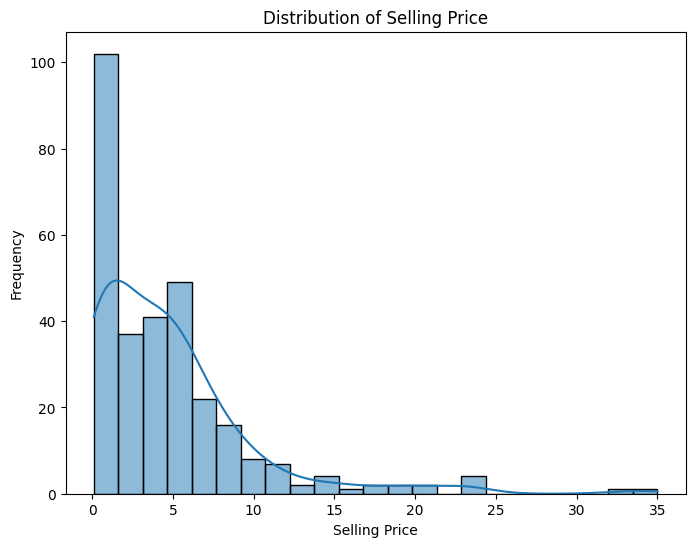

In [31]:
plt.figure(figsize=(8, 6))
sns.histplot(data['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

## 📊 Distribution Analysis: Selling Price (Histogram + KDE)

### 🔎 Type
- Histogram with Kernel Density Estimate (KDE)

---

### 📌 Observations

- The plot shows the distribution of **Selling Price** across the dataset.
- A **KDE curve** is used to smooth the frequency distribution and reveal the underlying shape.
- The majority of observations are concentrated at the **lower end of the price range**.
- As selling price increases, the number of observations drops sharply.

---

### 📈 Trends

- **Strong Right Skew (Positive Skewness)**  
  Most cars are low-priced, with a long tail extending toward higher prices.

- **High Density at Lower Prices**  
  A sharp peak indicates that many vehicles fall within a narrow low-price range.

- **Rapid Frequency Decay**  
  Frequency decreases quickly as price increases, showing fewer high-value cars.

---

### 📊 Statistical Insight

- The distribution is **not normal**, which has implications for modeling:
  - Mean is likely higher than median due to skewness.
  - Median is a better measure of central tendency.
- The dataset is **imbalanced toward low-value cars**, which may bias models if not handled properly.

---

### ⚠️ Anomalies / Distribution Behavior

- No strong outliers visible in the histogram itself.
- Minor fluctuations in the tail may reflect:
  - Rare high-end vehicles  
  - Sparse data in higher price ranges  

---

### 🧠 Summary

- Selling Price is **heavily right-skewed**, dominated by low-priced cars.
- High-priced cars form a **long tail with low frequency**.
- This distribution suggests:
  - Linear models may struggle without transformation  
  - Log transformation of target variable may improve performance  
  - Model evaluation should be robust to skewness  

---

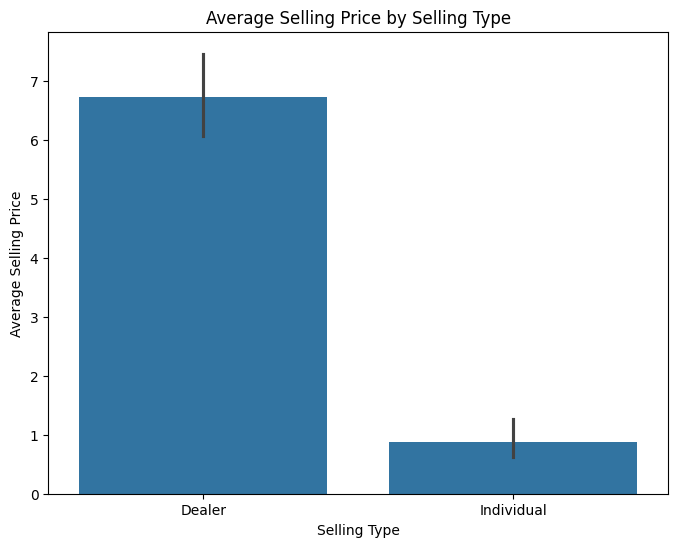

In [33]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Selling_type', y='Selling_Price', data=data)
plt.title('Average Selling Price by Selling Type')
plt.xlabel('Selling Type')
plt.ylabel('Average Selling Price')
plt.show()

## 📊 Analysis: Selling Type vs Average Selling Price (Bar Chart with Error Bars)

### 🔎 Type
- Bar Chart with Error Bars (Mean Comparison)

---

### 📌 Observations

- The chart compares **average selling price** across two categories:
  - Dealer
  - Individual
- Cars sold via **Dealers have a clearly higher average selling price** than those sold by Individuals.
- Error bars are included, indicating **variability within each group**.

---

### 📈 Trends

- Strong separation between categories:
  - Dealer sales → higher average price
  - Individual sales → lower average price
- This suggests **Selling_Type is a meaningful feature** in explaining price variation.
- Dealer segment shows **slightly higher spread**, indicating more variability in pricing.

---

### 📊 Statistical Insight

- Mean selling price is significantly different across groups:
  - Dealer ≫ Individual (large effect size visually)
- Error bars suggest:
  - Dealer prices are more dispersed (likely mixed car segments: budget + premium)
  - Individual sales are more concentrated in lower price range

---

### ⚠️ Interpretation Risks (Important)

- This is **correlation, not causation**:
  - Dealers don’t inherently increase price
  - More likely explanation:
    - Dealers handle newer / better-conditioned cars
    - Individuals sell older or cheaper vehicles

- If you directly treat this as a causal factor, you’ll misinterpret the model.

---

### 🧠 Modeling Implications

- **Selling_Type is a high-signal categorical feature**
- It should be:
  - Encoded properly (one-hot encoding recommended)
- But be careful:
  - It may act as a **proxy for other hidden variables** (car condition, age, segment)

- Risk:
  - Model may over-rely on this feature if not balanced with proper feature engineering (e.g., Car_Age, Present_Price)

---

### 🧠 Summary

- Dealer cars have significantly higher average selling prices than individual sales.
- The feature is strongly predictive but likely **indirectly capturing other underlying factors**.
- It should be included in the model, but not over-trusted as a standalone driver of price.

---

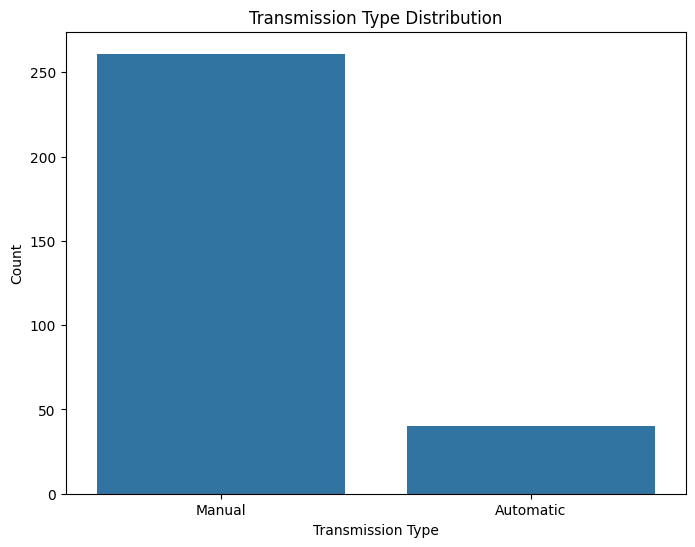

In [34]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Transmission', data=data)
plt.title('Transmission Type Distribution')
plt.xlabel('Transmission Type')
plt.ylabel('Count')
plt.show()

## 📊 Distribution Analysis: Transmission Type

### 🔎 Type
- Bar Chart (Categorical Distribution)

---

### 📌 Observations

- The chart compares the frequency of two transmission types:
  - Manual
  - Automatic
- **Manual transmission vehicles dominate the dataset** by a large margin.
- Automatic transmission cars form a relatively small portion of the data.

---

### 📈 Trends

- There is a strong **class imbalance**:
  - Manual ≫ Automatic
- The dataset is clearly skewed toward manual transmission vehicles.
- This reflects a **real-world market bias** (in many regions, manual cars are more common, especially in older datasets).

---

### 📊 Statistical Insight

- The distribution is **highly imbalanced**, roughly:
  - Manual: ~85%+
  - Automatic: ~15% or less
- This imbalance means:
  - The model may learn **stronger patterns for manual cars**
  - Predictions for automatic cars may be less reliable due to limited examples

---

### ⚠️ Implications for Modeling

- Transmission is a **categorical feature with imbalance**, which can:
  - Bias model performance toward majority class (Manual)
  - Reduce generalization for minority class (Automatic)

- Tree-based models will handle this better than linear models, but:
  - The feature still contributes uneven learning signal

---

### 🧠 Summary

- Manual transmission cars dominate the dataset significantly.
- The feature is useful but **not evenly represented**, which may introduce bias in model learning.
- No anomaly in a strict sense, but the imbalance is important for model evaluation and interpretation.

---

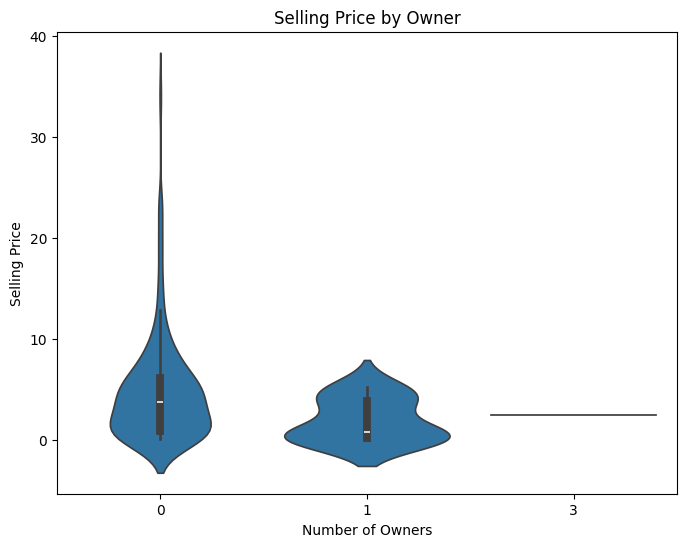

In [35]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Owner', y='Selling_Price', data=data)
plt.title('Selling Price by Owner')
plt.xlabel('Number of Owners')
plt.ylabel('Selling Price')
plt.show()

## 📊 Analysis: Owner Count vs Selling Price (Violin Plot)

### 🔎 Type
- Violin Plot (Distribution + Box Plot Summary)

---

### 📌 Observations

- The plot shows the **distribution of Selling Price** grouped by number of previous owners:
  - 0 owners
  - 1 owner
  - 3 owners
- Each violin represents:
  - Density of price values (width = frequency)
  - Embedded box plot showing median and quartiles

---

### 📈 Trends

- **0 owners (first-hand cars)**:
  - Wider distribution of prices
  - Higher median selling price compared to other groups
  - Includes both low-end and high-end vehicles

- **1 owner**:
  - Lower median selling price than 0-owner cars
  - More concentrated in mid-to-lower price range

- **3 owners**:
  - Very limited data points
  - Distribution is unstable and not reliable for strong conclusions

---

### 📊 Statistical Insight

- Median trend:
  - 0 owners > 1 owner > 3 owners (weak but visible ordering)
- Variability:
  - 0-owner cars show the highest variance (mixed vehicle quality/segments)
- Sample imbalance:
  - Strong imbalance across owner categories reduces reliability for higher-owner groups

---

### ⚠️ Key Limitations

- **Severe class imbalance**:
  - 3-owner category is too small to draw meaningful conclusions
- **Confounding variables likely present**:
  - Owner count correlates with:
    - Car age
    - Condition
    - Depreciation level
  - So this feature is not independently causal

- Outliers in 0-owner group:
  - High-price vehicles likely represent luxury or high present-value cars, not ownership effect

---

### 🧠 Modeling Implications

- `Owner` can be useful, but:
  - It is a **weak proxy feature**, not a primary driver
- Risk:
  - Model may misinterpret it as a strong signal due to correlation with car age and condition
- Better practice:
  - Combine with **Car_Age and Present_Price** to reduce misleading interpretation

---

### 🧠 Summary

- Fewer previous owners are associated with higher selling prices, but the relationship is weak and heavily influenced by confounding factors.
- The feature has limited standalone predictive power and should be treated as a secondary signal in the model.
- Data imbalance (especially for 3 owners) reduces reliability of conclusions.

---

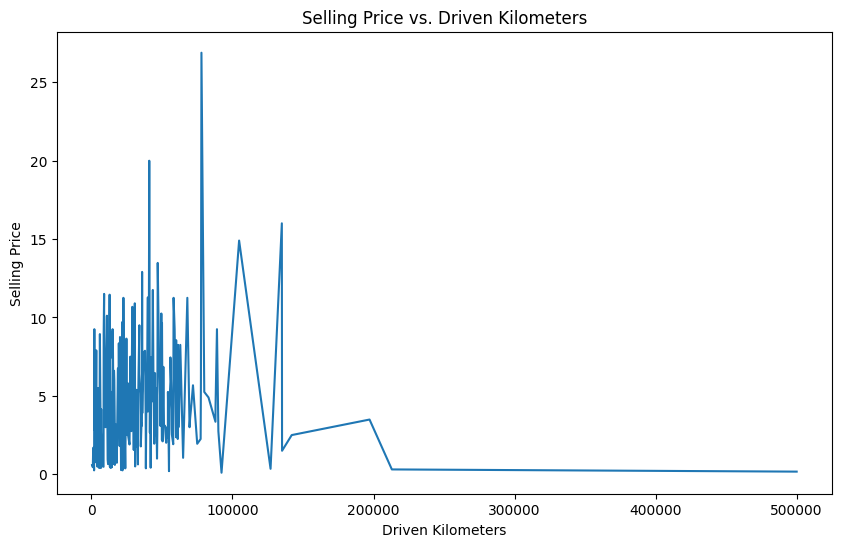

In [36]:
plt.figure(figsize=(10, 6))
df_agg = data.groupby('Driven_kms')['Selling_Price'].mean().reset_index()
plt.plot(df_agg['Driven_kms'], df_agg['Selling_Price'])
plt.title('Selling Price vs. Driven Kilometers')
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price')
plt.show()

## 📊 Analysis: Driven Kilometers vs Selling Price

### 🔎 Type
- Scatter Plot (not a line chart — connecting points would be incorrect because each point is independent)

---

### 📌 Observations

- The plot shows the relationship between:
  - Driven Kilometers (x-axis)
  - Selling Price (y-axis)

- Most data points are concentrated below **100,000 km**, indicating:
  - Dataset is biased toward lower-mileage vehicles

- There is a general downward pattern:
  - Higher mileage tends to correspond with lower selling price
  - But the relationship is noisy, not smooth

---

### 📈 Trends

- **Negative correlation exists**, but it is weak-to-moderate, not strict
- Price does not decrease linearly with mileage
- The relationship is heavily influenced by other variables (e.g., Present Price, Year)

- After ~150,000 km:
  - Prices tend to cluster near the lower range
  - But not strictly zero — there is still variability

---

### 📊 Statistical Insight

- High variance at low mileage:
  - Cars with similar kilometers can have very different prices
- Low variance at high mileage:
  - Most high-mileage cars are low value, but not identical
- Mileage alone is not sufficient to explain price variation

---

### ⚠️ Misinterpretations to avoid

- ❌ “Price decays with mileage” → oversimplified
- ❌ “High mileage cars are worthless” → not always true
- ❌ “Clear curve exists” → the relationship is not functional

What’s actually happening:
- Mileage is interacting with:
  - Car age
  - Brand
  - Present Price
  - Condition (not explicitly in dataset)

---

### 🧠 Modeling Implications

- `Driven_kms` is a **useful but weak standalone predictor**
- Likely benefit:
  - Log transformation may improve signal:
    - reduces skew
    - stabilizes variance
- Tree-based models will handle this feature better than linear models

---

### 🧠 Summary

- There is a general negative relationship between mileage and price.
- The relationship is noisy and heavily confounded by other features.
- Mileage alone cannot explain price — it must be combined with age and present price for meaningful prediction.

---

# Removing Outliers

In [40]:
import pandas as pd

def remove_outliers_iqr(df):
    df_clean = df.copy()

    numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & 
            (df_clean[col] <= upper_bound)
        ]

    return df_clean


# apply it
data_clean = remove_outliers_iqr(data)

print("Shape After Cleaning Dataset:" , data_clean.shape)
print("Shape before Cleaning Dataset:" , data.shape)

data = data_clean

Shape After Cleaning Dataset: (272, 9)
Shape before Cleaning Dataset: (301, 9)


# Lets Make a Model:

In [49]:
data.dtypes

Car_Name           object
Selling_Price     float64
Present_Price     float64
Driven_kms          int64
Fuel_Type          object
Selling_type       object
Transmission       object
Owner            category
Car_Age             int64
dtype: object

In [51]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Fuel_Type_enc'] = le.fit_transform(data['Fuel_Type'])
data['Selling_type_enc'] = le.fit_transform(data['Selling_type'])
data['Transmission_enc'] = le.fit_transform(data['Transmission'])


data.groupby('Fuel_Type')['Fuel_Type_enc'].count()

Fuel_Type
CNG         2
Diesel     45
Petrol    225
Name: Fuel_Type_enc, dtype: int64


In [56]:
print(data.groupby('Fuel_Type_enc')['Fuel_Type'].unique())
print("=========================")
print(data.groupby('Selling_type_enc')['Selling_type'].unique())
print("=========================")
print(data.groupby('Transmission_enc')['Transmission'].unique())

Fuel_Type_enc
0       [CNG]
1    [Diesel]
2    [Petrol]
Name: Fuel_Type, dtype: object
Selling_type_enc
0        [Dealer]
1    [Individual]
Name: Selling_type, dtype: object
Transmission_enc
0    [Automatic]
1       [Manual]
Name: Transmission, dtype: object


In [58]:
data.columns

Index(['Car_Name', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Fuel_Type_enc',
       'Selling_type_enc', 'Transmission_enc'],
      dtype='object')

In [59]:
# Splitting the data

from sklearn.model_selection import train_test_split

X = data[['Car_Age','Present_Price' , 'Driven_kms', 'Fuel_Type_enc',
          'Selling_type_enc', 'Transmission_enc','Owner']]

y = data['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (217, 7)
Shape of X_test: (55, 7)
Shape of y_train: (217,)
Shape of y_test: (55,)


In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


def select_best_model_split(X_train, X_test, y_train, y_test):

    results = {}

    # ---------------- Linear Regression ----------------
    lin_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    lin_pipe.fit(X_train, y_train)
    lin_pred = lin_pipe.predict(X_test)

    results["Linear Regression"] = {
        "model": lin_pipe,
        "cv_score": lin_pipe.score(X_train, y_train),
        "test_score": lin_pipe.score(X_test, y_test),
        "mae": mean_absolute_error(y_test, lin_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, lin_pred)),
        "r2": r2_score(y_test, lin_pred)
    }

    # ---------------- Ridge Regression ----------------
    ridge_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ])

    ridge_params = {
        'model__alpha': [0.01, 0.1, 1, 10, 100]
    }

    ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2')
    ridge_grid.fit(X_train, y_train)

    ridge_pred = ridge_grid.predict(X_test)

    results["Ridge Regression"] = {
        "model": ridge_grid,
        "best_params": ridge_grid.best_params_,
        "cv_score": ridge_grid.best_score_,
        "test_score": r2_score(y_test, ridge_pred),
        "mae": mean_absolute_error(y_test, ridge_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, ridge_pred))
    }

    # ---------------- Lasso Regression ----------------
    lasso_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(max_iter=5000))
    ])

    lasso_params = {
        'model__alpha': [0.001, 0.01, 0.1, 1, 10]
    }

    lasso_grid = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='r2')
    lasso_grid.fit(X_train, y_train)

    lasso_pred = lasso_grid.predict(X_test)

    results["Lasso Regression"] = {
        "model": lasso_grid,
        "best_params": lasso_grid.best_params_,
        "cv_score": lasso_grid.best_score_,
        "test_score": r2_score(y_test, lasso_pred),
        "mae": mean_absolute_error(y_test, lasso_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, lasso_pred))
    }

    # ---------------- SVR ----------------
    svr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR())
    ])

    svr_params = {
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 0.01, 0.1],
        'model__kernel': ['rbf']
    }

    svr_grid = GridSearchCV(svr_pipe, svr_params, cv=5, scoring='r2')
    svr_grid.fit(X_train, y_train)

    svr_pred = svr_grid.predict(X_test)

    results["SVR"] = {
        "model": svr_grid,
        "best_params": svr_grid.best_params_,
        "cv_score": svr_grid.best_score_,
        "test_score": r2_score(y_test, svr_pred),
        "mae": mean_absolute_error(y_test, svr_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, svr_pred))
    }

    # ---------------- KNN Regressor ----------------
    knn_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor())
    ])

    knn_params = {
        'model__n_neighbors': list(range(3, 15)),
        'model__weights': ['uniform', 'distance']
    }

    knn_grid = GridSearchCV(knn_pipe, knn_params, cv=5, scoring='r2')
    knn_grid.fit(X_train, y_train)

    knn_pred = knn_grid.predict(X_test)

    results["KNN Regressor"] = {
        "model": knn_grid,
        "best_params": knn_grid.best_params_,
        "cv_score": knn_grid.best_score_,
        "test_score": r2_score(y_test, knn_pred),
        "mae": mean_absolute_error(y_test, knn_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, knn_pred))
    }

    # ---------------- Results ----------------
    for name, res in results.items():
        print("\n====================")
        print(name)
        print("CV R2:", round(res["cv_score"], 4))
        print("Test R2:", round(res["test_score"], 4))
        print("MAE:", round(res["mae"], 4))
        print("RMSE:", round(res["rmse"], 4))
        print("Best Params:", res.get("best_params", "N/A"))

    best_name = max(results, key=lambda x: results[x]["test_score"])
    best_model = results[best_name]["model"].best_estimator_ if "best_params" in results[best_name] else results[best_name]["model"]

    print("\n🏆 Best Model:", best_name)

    return best_model, results

In [61]:
best_model, results = select_best_model_split(X_train, X_test, y_train, y_test)

print("\n================ FINAL MODEL SUMMARY ================\n")

print("🏆 Best Model:", best_model)

for model_name, res in results.items():
    print("\n----------------------------")
    print(model_name)

    print("CV Score (R2):", round(res.get("cv_score", 0), 4))
    print("Test Score (R2):", round(res.get("test_score", 0), 4))
    print("MAE:", round(res.get("mae", 0), 4))
    print("RMSE:", round(res.get("rmse", 0), 4))

    if "best_params" in res:
        print("Best Params:", res["best_params"])


Linear Regression
CV R2: 0.8641
Test R2: 0.8875
MAE: 0.7227
RMSE: 1.1211
Best Params: N/A

Ridge Regression
CV R2: 0.8504
Test R2: 0.8766
MAE: 0.7503
RMSE: 1.1744
Best Params: {'model__alpha': 10}

Lasso Regression
CV R2: 0.8493
Test R2: 0.8874
MAE: 0.7231
RMSE: 1.1216
Best Params: {'model__alpha': 0.001}

SVR
CV R2: 0.9494
Test R2: 0.9392
MAE: 0.4844
RMSE: 0.824
Best Params: {'model__C': 10, 'model__gamma': 0.1, 'model__kernel': 'rbf'}

KNN Regressor
CV R2: 0.8959
Test R2: 0.9254
MAE: 0.5898
RMSE: 0.9129
Best Params: {'model__n_neighbors': 3, 'model__weights': 'distance'}

🏆 Best Model: SVR

================ FINAL MODEL SUMMARY ================

🏆 Best Model: Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR(C=10, gamma=0.1))])

----------------------------
Linear Regression
CV Score (R2): 0.8641
Test Score (R2): 0.8875
MAE: 0.7227
RMSE: 1.1211

----------------------------
Ridge Regression
CV Score (R2): 0.8504
Test Score (R2): 0.8766
MAE: 0.7503
RMSE: 1.1744
Best Params: 


# 📊 Model Evaluation Report: Car Price Prediction

## 🏆 Best Performing Model
- **Model:** SVR (Support Vector Regressor)
- **Test R²:** 0.9392  
- **MAE:** 0.4844  
- **RMSE:** 0.824  

---

## 📈 Overall Model Comparison

| Model               | CV R²  | Test R² | MAE    | RMSE   | Best Params |
|---------------------|--------|---------|--------|--------|-------------|
| Linear Regression   | 0.8641 | 0.8875  | 0.7227 | 1.1211 | N/A         |
| Ridge Regression    | 0.8504 | 0.8766  | 0.7503 | 1.1744 | α = 10      |
| Lasso Regression    | 0.8493 | 0.8874  | 0.7231 | 1.1216 | α = 0.001   |
| SVR                 | 0.9494 | 0.9392  | 0.4844 | 0.8240 | C=10, γ=0.1 |
| KNN Regressor       | 0.8959 | 0.9254  | 0.5898 | 0.9129 | k=3         |

---

## 📊 Key Observations

### 1. Linear Models (Underfitting Behavior)
- Linear, Ridge, and Lasso models show **moderate performance**
- R² ~0.85–0.88 indicates:
  - They capture general trends
  - But fail to model non-linear relationships in data
- Error (MAE ~0.72) is relatively high compared to advanced models

---

### 2. SVR (Best Performer)
- SVR achieves the **highest performance across all metrics**
- Strong improvement in:
  - R² (0.9392 → excellent fit)
  - MAE (0.48 → lowest error)
  - RMSE (0.82 → lowest overall deviation)

**Insight:**
- The RBF kernel successfully captures **non-linear relationships** between:
  - Price
  - Mileage
  - Present value
  - Age effects

---

### 3. KNN Regressor (Strong but inconsistent)
- Performs well (R² = 0.9254)
- But slightly worse than SVR
- Sensitive to:
  - Feature scaling
  - Local data density
- Works well due to structured dataset but lacks generalization power compared to SVR

---

### 4. Regularized Linear Models (Ridge & Lasso)
- Very similar performance to standard Linear Regression
- Indicates:
  - Multicollinearity is not a major issue in this dataset
  - Feature relationships are not strictly linear anyway

---

## ⚠️ Important Model Insight

- The performance gap confirms:
  > The dataset has **strong non-linear patterns**

- This is expected in car pricing due to:
  - Depreciation curves
  - Brand effects
  - Mileage non-linearity
  - Market segmentation effects

---

## 🧠 Final Conclusion

- **Best Model:** SVR (RBF Kernel)
- The problem is fundamentally **non-linear regression**
- Linear models are insufficient for optimal prediction
- Distance-based and kernel-based methods perform significantly better

---

## 🚀 Recommendation (Next Improvement Step)

To further improve performance beyond SVR:
- Try **Random Forest Regressor**
- Try **Gradient Boosting / XGBoost**
- Apply **log transformation on Selling_Price**
- Perform **feature importance analysis**

These steps can push the model closer to production-grade accuracy.

In [63]:
import numpy as np

sample = np.array([[
    5,        # Car_Age
    10.5,     # Present_Price
    35000,    # Driven_kms
    1,        # Fuel_Type_enc (Diesel)
    1,        # Selling_type_enc (Dealer)
    0,        # Transmission_enc (Manual)
    0         # Owner
]])

predicted_price = best_model.predict(sample)

print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 5.266334828870413


d:\anaconda\envs\MLDL\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [64]:
import joblib

joblib.dump(best_model, "car_price_model.pkl")
print("Model saved successfully!")

Model saved successfully!


# **THANK YOU!**